### Chargement des librairies

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

Confirmer la bonne installation des dépendances.

/var/folders/lp/_7p379t92_d70xn78jbmgbwr0000gn/T/ipykernel_94582/868110576.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


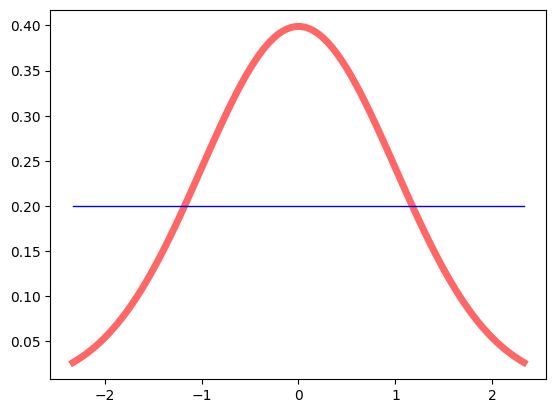

In [2]:
fig, ax = plt.subplots()
x = np.linspace(norm.ppf(0.01),
                norm.ppf(0.99), 100)

ax.plot(x, norm.pdf(x),
       'r-', lw=5, alpha=0.6)

ax.plot(x, np.full(len(x), 0.2),
       'b-', lw=1)

fig.show()

Extraire des informations sur les protéines de E. coli à partir du fichier XML, puis les exploiter (par exemple, pour les afficher, les filtrer ou les stocker dans une base de données).

In [5]:
from xml.etree.ElementTree import parse, dump
# Parse the E.Coli proteome XML Document
tree = parse('data/uniprot-proteome_UP000000625.xml')
root = tree.getroot()
ns = '{http://uniprot.org/uniprot}' # MANDATORY PREFIX FOR ANY SEARCH within document
# Store all entries aka proteins in a list of xml nodes
proteins = root.findall(ns + 'entry')
# Display the xml subtree of the first protein 
dump(proteins[0])

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1989-10-01" modified="2020-08-12" version="166">
<ns0:accession>P11446</ns0:accession>
<ns0:accession>Q2M8Q3</ns0:accession>
<ns0:name>ARGC_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName evidence="1 4">N-acetyl-gamma-glutamyl-phosphate reductase</ns0:fullName>
<ns0:shortName evidence="1 4">AGPR</ns0:shortName>
<ns0:ecNumber evidence="1 2">1.2.1.38</ns0:ecNumber>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName evidence="1 3">N-acetyl-glutamate semialdehyde dehydrogenase</ns0:fullName>
<ns0:shortName evidence="1 3">NAGSA dehydrogenase</ns0:shortName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary" evidence="1">argC</ns0:name>
<ns0:name type="ordered locus">b3958</ns0:name>
<ns0:name type="ordered locus">JW3930</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" 

Ce code sert à trouver et afficher la protéine spécifique dont l'identifiant UniProt est "P31224" dans le protéome d'E. coli.

In [6]:
# Find the xml subtree of a protein with accession "P31224"
for entry in proteins:
    accessions = entry.findall(ns+"accession")
    for acc in accessions:
        if acc.text == "P31224":
            dump(entry)
            break

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1993-07-01" modified="2020-08-12" version="187">
<ns0:accession>P31224</ns0:accession>
<ns0:accession>Q2MBW5</ns0:accession>
<ns0:name>ACRB_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName>Multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName>AcrAB-TolC multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:alternativeName>
<ns0:alternativeName>
<ns0:fullName>Acridine resistance protein B</ns0:fullName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary">acrB</ns0:name>
<ns0:name type="synonym">acrE</ns0:name>
<ns0:name type="ordered locus">b0462</ns0:name>
<ns0:name type="ordered locus">JW0451</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" id="83333" />
<ns0:lineage>
<ns0:taxon>Bacteria</ns0:taxon>
<ns0:taxon>Proteo

### Exploration des données

In [7]:
import pandas as pd

In [25]:
df = pd.read_csv('data/TCL_wt1.tsv', sep="\t",
    encoding="utf-8")

In [38]:
df.shape

(2024, 7)

In [26]:
df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075816993,-3.721334942,0.000055,4.260067469
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810458,-3.429568818,0.000351,3.45462743
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614379,-3.284695189,0.000027,4.571899347
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,#VALEUR!,#VALEUR!,NaN,#VALEUR!
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108496732,-3.204276506,0.019963,1.699767669


In [27]:
df.tail()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,#VALEUR!,#VALEUR!,NaN,#VALEUR!
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579738562,0.65968582,0.002226,2.652390664
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754901961,0.811390435,0.000068,4.16495627
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039216,0.846424487,0.035928,1.444561032
2023,P76042,Putative ABC transporter periplasmic-binding p...,ycjN,#VALEUR!,#VALEUR!,NaN,#VALEUR!


In [28]:
df.columns

Index(['Accession', 'Description', 'Gene Symbol',
       'Corrected Abundance ratio (1.53)', 'Log2 Corrected Abundance Ratio',
       'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)',
       '-LOG10 Adj.P-val'],
      dtype='str')

In [35]:
df.dtypes

Accession                                                           str
Description                                                         str
Gene Symbol                                                         str
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

In [34]:
# Convertir plusieurs colonnes en float64
numeric_cols = ["Log2 Corrected Abundance Ratio", "-LOG10 Adj.P-val", "Corrected Abundance ratio (1.53)"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [30]:
df.info

<bound method DataFrame.info of      Accession                                        Description Gene Symbol  \
0       P75936  Basal-body rod modification protein FlgD OS=Es...        flgD   
1       P76231  Uncharacterized protein YeaC OS=Escherichia co...        yeaC   
2       P0A8S9  Flagellar transcriptional regulator FlhD OS=Es...        flhD   
3       P0CE48  Elongation factor Tu 2 OS=Escherichia coli (st...        tufB   
4       P05706  PTS system glucitol/sorbitol-specific EIIA com...        srlB   
...        ...                                                ...         ...   
2019    P24240  6-phospho-beta-glucosidase AscB OS=Escherichia...        ascB   
2020    P0A917  Outer membrane protein X OS=Escherichia coli (...        ompX   
2021    P02931  Outer membrane protein F OS=Escherichia coli (...        ompF   
2022    P0AB40  Multiple stress resistance protein BhsA OS=Esc...        bhsA   
2023    P76042  Putative ABC transporter periplasmic-binding p...        ycjN

In [31]:
df.describe()

,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)
count,1.750000e+03
mean,8.238311e-01
std,3.506349e-01
min,1.034030e-08
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


In [32]:
df.dropna()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075816993,-3.721334942,0.000055,4.260067469
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810458,-3.429568818,0.000351,3.45462743
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614379,-3.284695189,0.000027,4.571899347
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108496732,-3.204276506,0.019963,1.699767669
5,P29744,Flagellar hook-associated protein 3 OS=Escheri...,flgL,0.124183007,-3.009460329,0.036746,1.434786589
...,...,...,...,...,...,...,...
2011,P77330,Prophage lipoprotein Bor homolog OS=Escherichi...,borD,1.535947712,0.619129104,0.310725,0.507623276
2016,P02930,Outer membrane protein TolC OS=Escherichia col...,tolC,1.552287582,0.634395861,0.013373,1.873756665
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579738562,0.65968582,0.002226,2.652390664
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754901961,0.811390435,0.000068,4.16495627


Créer un nouveau dataframe à partir des colonnes d'un autre dataframe.

In [36]:
values = df[['Description', 'Gene Symbol']]

In [37]:
values.shape

(2024, 2)

In [40]:
values.head()

,Description,Gene Symbol
0,Basal-body rod modification protein FlgD OS=Es...,flgD
1,Uncharacterized protein YeaC OS=Escherichia co...,yeaC
2,Flagellar transcriptional regulator FlhD OS=Es...,flhD
3,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB
4,PTS system glucitol/sorbitol-specific EIIA com...,srlB


In [41]:
values.tail()

,Description,Gene Symbol
2019,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB
2020,Outer membrane protein X OS=Escherichia coli (...,ompX
2021,Outer membrane protein F OS=Escherichia coli (...,ompF
2022,Multiple stress resistance protein BhsA OS=Esc...,bhsA
2023,Putative ABC transporter periplasmic-binding p...,ycjN


In [42]:
values.columns

Index(['Description', 'Gene Symbol'], dtype='str')

In [45]:
values.dtypes

Description    str
Gene Symbol    str
dtype: object

In [48]:
values.info

<bound method DataFrame.info of                                             Description Gene Symbol
0     Basal-body rod modification protein FlgD OS=Es...        flgD
1     Uncharacterized protein YeaC OS=Escherichia co...        yeaC
2     Flagellar transcriptional regulator FlhD OS=Es...        flhD
3     Elongation factor Tu 2 OS=Escherichia coli (st...        tufB
4     PTS system glucitol/sorbitol-specific EIIA com...        srlB
...                                                 ...         ...
2019  6-phospho-beta-glucosidase AscB OS=Escherichia...        ascB
2020  Outer membrane protein X OS=Escherichia coli (...        ompX
2021  Outer membrane protein F OS=Escherichia coli (...        ompF
2022  Multiple stress resistance protein BhsA OS=Esc...        bhsA
2023  Putative ABC transporter periplasmic-binding p...        ycjN

[2024 rows x 2 columns]>

In [51]:
values.describe()

,Description,Gene Symbol
count,2024,2017
unique,2024,2015
top,Basal-body rod modification protein FlgD OS=Es...,rlmC; rlmD
freq,1,2


Obtenir les colonnes et lignes spécifiques.

In [57]:
values.iloc[:5]

,Description,Gene Symbol
0,Basal-body rod modification protein FlgD OS=Es...,flgD
1,Uncharacterized protein YeaC OS=Escherichia co...,yeaC
2,Flagellar transcriptional regulator FlhD OS=Es...,flhD
3,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB
4,PTS system glucitol/sorbitol-specific EIIA com...,srlB


In [61]:
values.iloc[:, -1]

0       flgD
1       yeaC
2       flhD
3       tufB
4       srlB
        ... 
2019    ascB
2020    ompX
2021    ompF
2022    bhsA
2023    ycjN
Name: Gene Symbol, Length: 2024, dtype: str

In [64]:
df.iloc[:5, [0,2,3]]

,Accession,Gene Symbol,Corrected Abundance ratio (1.53)
0,P75936,flgD,0.075817
1,P76231,yeaC,0.092810
2,P0A8S9,flhD,0.102614
3,P0CE48,tufB,NaN
4,P05706,srlB,0.108497


Le type des valeurs peut-être spécifié à la lecture :

In [67]:
df = pd.read_csv(
    'data/TCL_wt1.tsv',
    sep="\t",
    dtype={
        'Accession': str,
        'Description': str,
        'Gene Symbol': str,
        'Corrected Abundance ratio (1.53)': float,
        'Log2 Corrected Abundance Ratio': float,
        'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)': float,
        '-LOG10 Adj.P-val': float
    },
    na_values=['#VALEUR!']  # Remplace '#VALEUR!' par NaN
)

In [68]:
df = df.astype({'Log2 Corrected Abundance Ratio': float, '-LOG10 Adj.P-val': float } )

La méthode loc permet de selectionner toutes les lignes/colonnes respectant certaines contraintes.

In [69]:
df.loc[(df['-LOG10 Adj.P-val'] > 0 )  & (df['Log2 Corrected Abundance Ratio'] > 0.0 ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1938,P68919,50S ribosomal protein L25 OS=Escherichia coli ...,rplY,1.010458,0.015009,2.035974e-01,0.691228
1939,P0ACG1,DNA-binding protein StpA OS=Escherichia coli (...,stpA,1.013072,0.018737,1.936673e-01,0.712944
1940,P0A903,Outer membrane protein assembly factor BamC OS...,bamC,1.020915,0.029863,3.957145e-01,0.402618
1945,P0ADE4,Translocation and assembly module subunit TamA...,tamA; ytfM,1.024183,0.034474,2.625522e-03,2.580784
1946,P02943,Maltoporin OS=Escherichia coli (strain K12) OX...,lamB,1.030065,0.042736,3.135847e-03,2.503645
1947,P77774,Outer membrane protein assembly factor BamB OS...,bamB,1.035294,0.050041,4.857703e-01,0.313569
1948,P0A940,Outer membrane protein assembly factor BamA OS...,bamA,1.039869,0.056402,1.228502e-01,0.910624
1955,P0AEQ1,Protein GlcG OS=Escherichia coli (strain K12) ...,glcG,1.050327,0.070838,2.177041e-02,1.662133
1957,P09169,Protease 7 OS=Escherichia coli (strain K12) OX...,ompT,1.052288,0.073529,1.085198e-01,0.964491
1962,P05825,Ferrienterobactin receptor OS=Escherichia coli...,fepA,1.076471,0.106309,1.524348e-02,1.816916


In [70]:
df.loc[ df['Gene Symbol'].isin(['fadR', 'arcA'] ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1862,P0A8V6,Fatty acid metabolism regulator protein OS=Esc...,fadR,0.901307,-0.149909,0.000351,3.454627
1898,P0A9Q1,Aerobic respiration control protein ArcA OS=Es...,arcA,0.931373,-0.102570,0.000136,3.866640
